In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [3]:
import pandas as pd

df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 15


In [5]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 107


In [9]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
print("Sex:")
print(df["sex"].value_counts())

print("\nPassenger Class:")
print(df["pclass"].value_counts())

print("\nEmbarked:")
print(df["embarked"].value_counts())

Sex:
sex
male      577
female    314
Name: count, dtype: int64

Passenger Class:
pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embarked:
embarked
S    644
C    168
Q     77
Name: count, dtype: int64


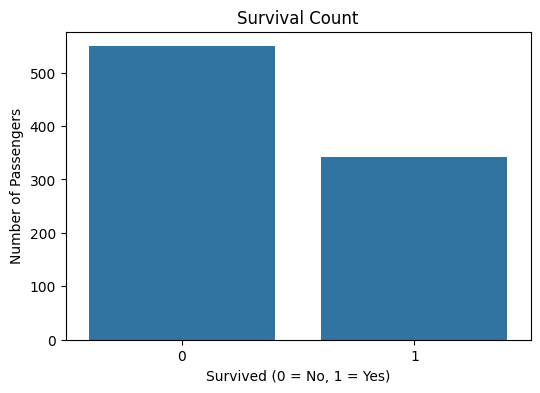

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="survived", data=df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

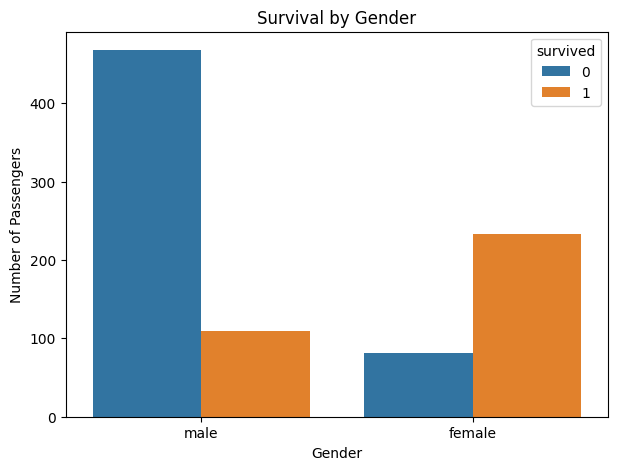

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(x="sex", hue="survived", data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

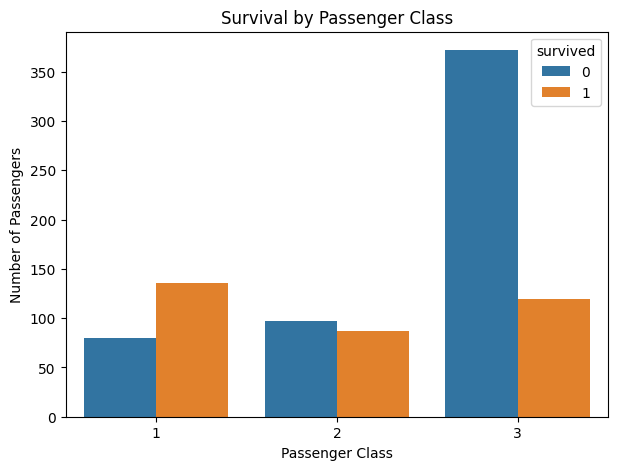

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(x="pclass", hue="survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

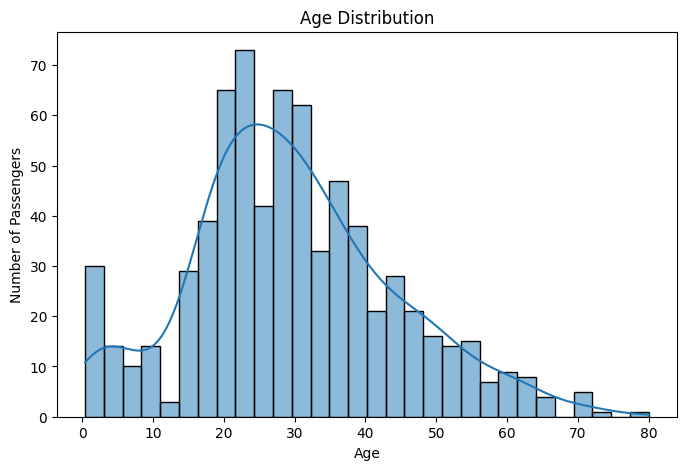

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"].dropna(), bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

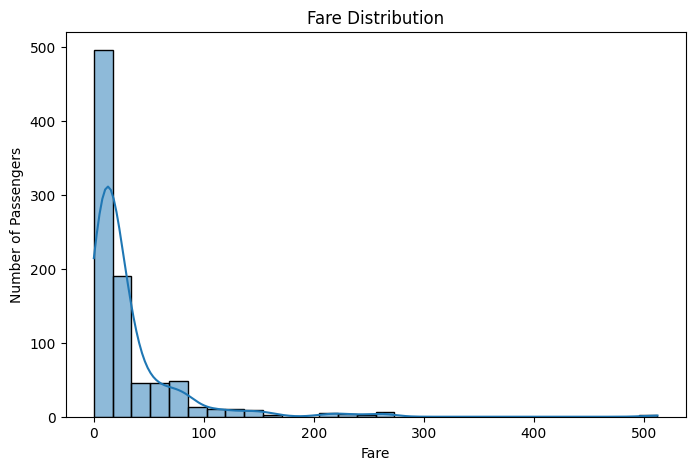

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["fare"], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

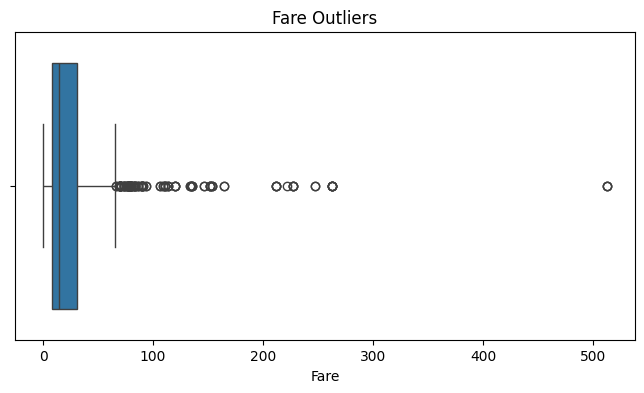

In [16]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["fare"])

plt.title("Fare Outliers")
plt.xlabel("Fare")

plt.show()

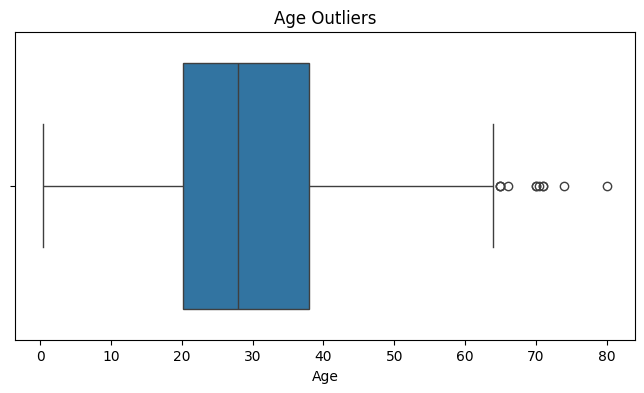

In [17]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["age"].dropna())

plt.title("Age Outliers")
plt.xlabel("Age")

plt.show()

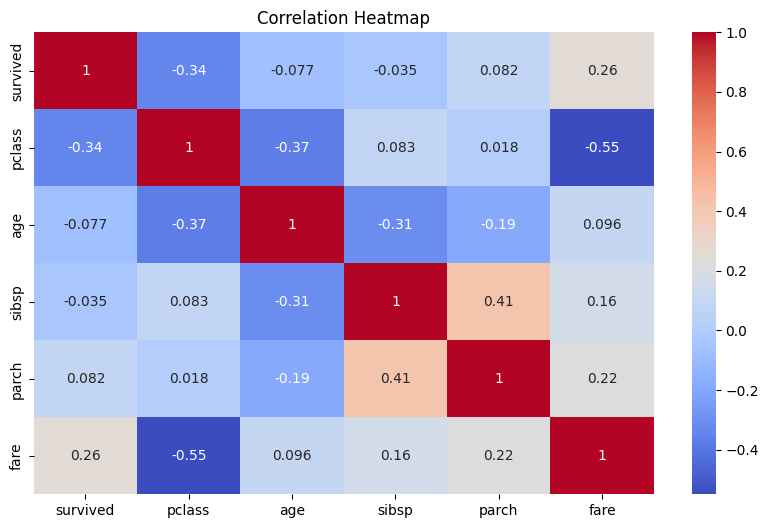

In [18]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
survival_rate = df["survived"].mean() * 100

print("Overall Survival Rate:", round(survival_rate, 2), "%")

Overall Survival Rate: 38.38 %


In [20]:
gender_survival = df.groupby("sex")["survived"].mean() * 100

print(gender_survival.round(2))

sex
female    74.20
male      18.89
Name: survived, dtype: float64


In [21]:
class_survival = df.groupby("pclass")["survived"].mean() * 100

print(class_survival.round(2))

pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64


In [22]:
age_survival = df.groupby("survived")["age"].mean()

print(age_survival.round(2))

survived
0    30.63
1    28.34
Name: age, dtype: float64


In [23]:
fare_survival = df.groupby("survived")["fare"].mean()

print(fare_survival.round(2))

survived
0    22.12
1    48.40
Name: fare, dtype: float64


## Key Findings

- The Titanic dataset contains 891 rows and 15 columns.
- The dataset contains both numerical and categorical variables.
- Missing values were found in Age, Deck, and Embarked columns.
- Duplicate rows were identified during the analysis.
- Survival varied across passenger genders.
- Passenger class showed differences in survival rates.
- The Age distribution represents passengers from different age groups.
- Fare values showed variation and potential outliers.
- Correlation analysis was used to understand relationships between numerical variables.
- Overall survival rate was calculated to understand the proportion of passengers who survived.

## Conclusion

This Exploratory Data Analysis provided an overview of the Titanic dataset by examining its structure, data types, missing values, duplicates, statistical characteristics, distributions, and relationships between variables.

Different visualizations were used to identify patterns in passenger survival, gender, passenger class, age, and fare.

The analysis demonstrates how Exploratory Data Analysis can be used to understand a dataset and identify important patterns and potential data quality issues before further analysis or modeling.

In [24]:
df.to_csv("titanic_eda_dataset.csv", index=False)

print("EDA dataset saved successfully!")

EDA dataset saved successfully!
